In [63]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4, 4] 
plt.rcParams['figure.dpi'] = 300

In [64]:
t = np.linspace(0, 100, 1000)
y_0 = [0.95, 0.05, 0]

def SIR(y, t, beta, gamma, mu=0):
    return [ mu -beta * y[0] * y[1] - mu * y[0], beta * y[0] * y[1] - gamma * y[1] - mu * y[1], gamma * y[1] - mu * y[2] ]

In [65]:
beta = 0.4
gamma = 0.1
sol = sp.integrate.odeint(SIR, y_0, t, args=(beta, gamma))

In [84]:
def analyse_SIR(beta, gamma, mu, y0, t):
    sol = sp.integrate.odeint(SIR, y0, t, args=(beta, gamma, mu))
    plt.tight_layout
    plt.ylim(0,1)
    plt.plot(t, sol[:,0], label="S")
    plt.plot(t, sol[:,1], label="I")
    plt.plot(t, sol[:,2], label="R")
    plt.legend()
    plt.show()
    sol_dot = np.array([SIR(y,t, beta, gamma) for y in sol])
    plt.plot(sol[:,0], sol_dot[:,0], label="S")
    plt.plot(sol[:,1], sol_dot[:,1], label="I")
    plt.plot(sol[:,2], sol_dot[:,2], label="R")
    plt.legend()
    plt.show()
    return sol, sol_dot

In [85]:
beta = 1
gamma = 1.2
mu = 0
y0 = [0.95, 0.05]
t = np.linspace(0, 100, 1000)
analyse_SIR(beta, gamma, mu, y0, t)

IndexError: index 2 is out of bounds for axis 0 with size 2

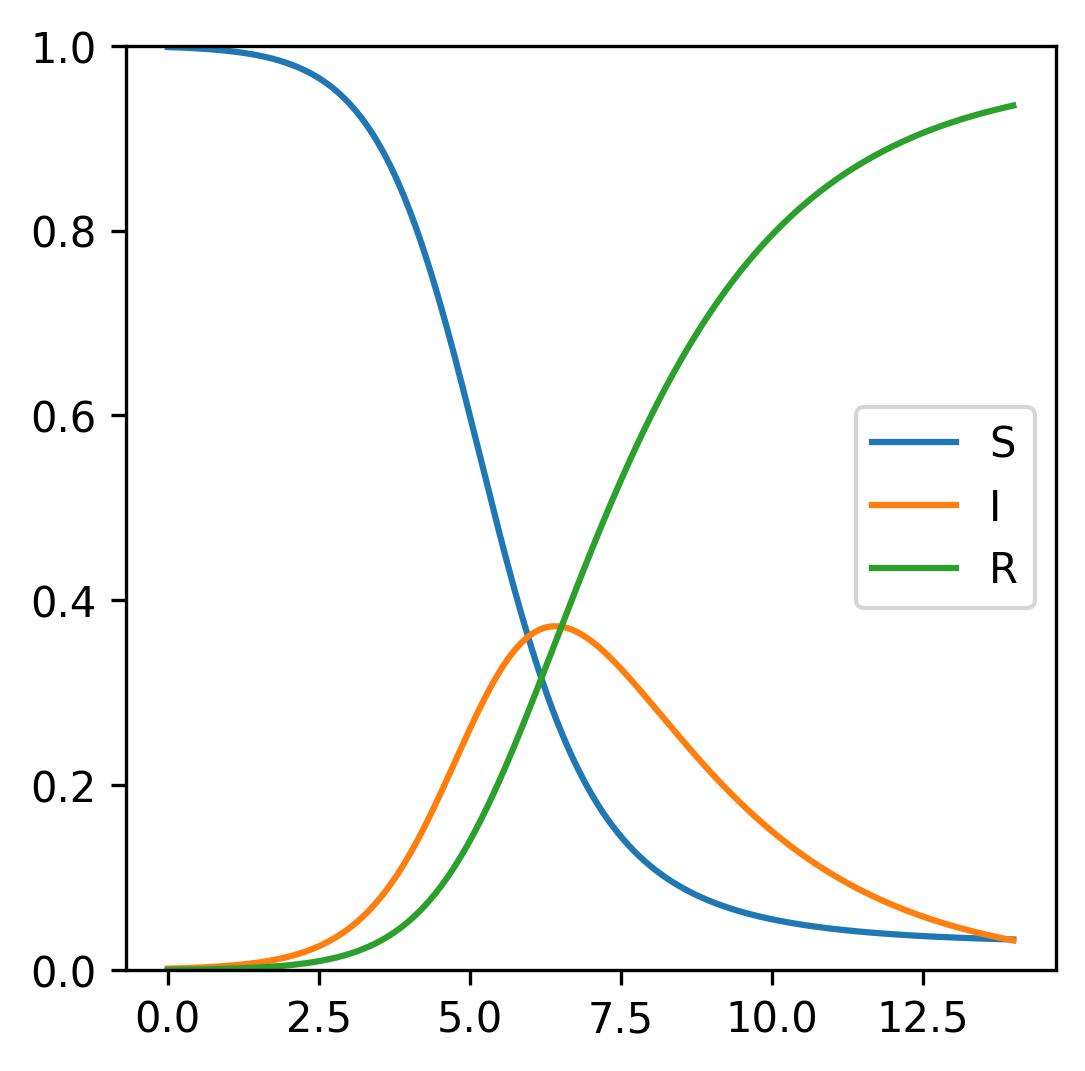

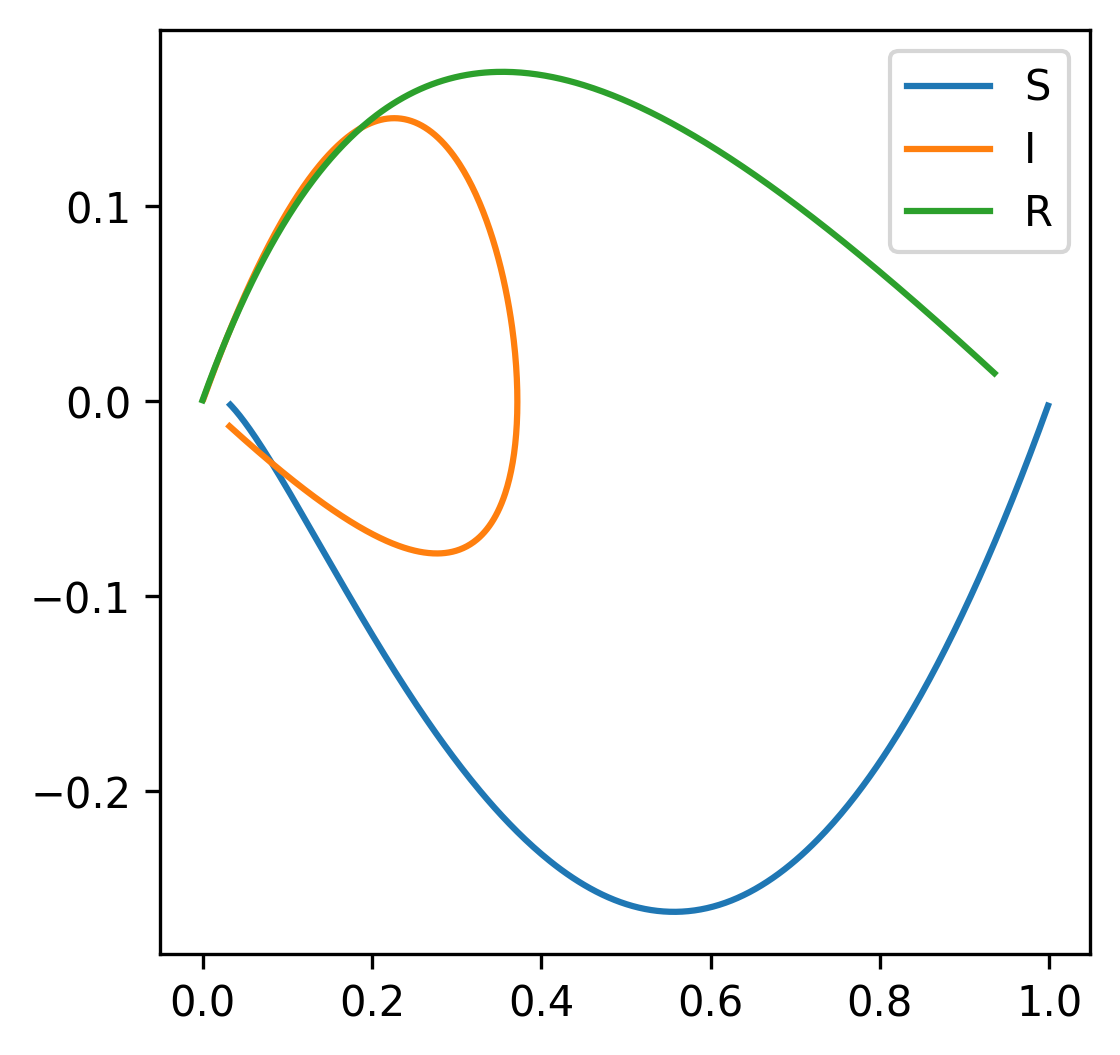

array([0.99868938, 0.00131062, 0.        ])

In [88]:
t = np.linspace(0,14, 1000)
y0 = np.array([762, 1, 0])/763
sol, sol_dot = analyse_SIR(1.66, 1/2.2, 0, y0, t)

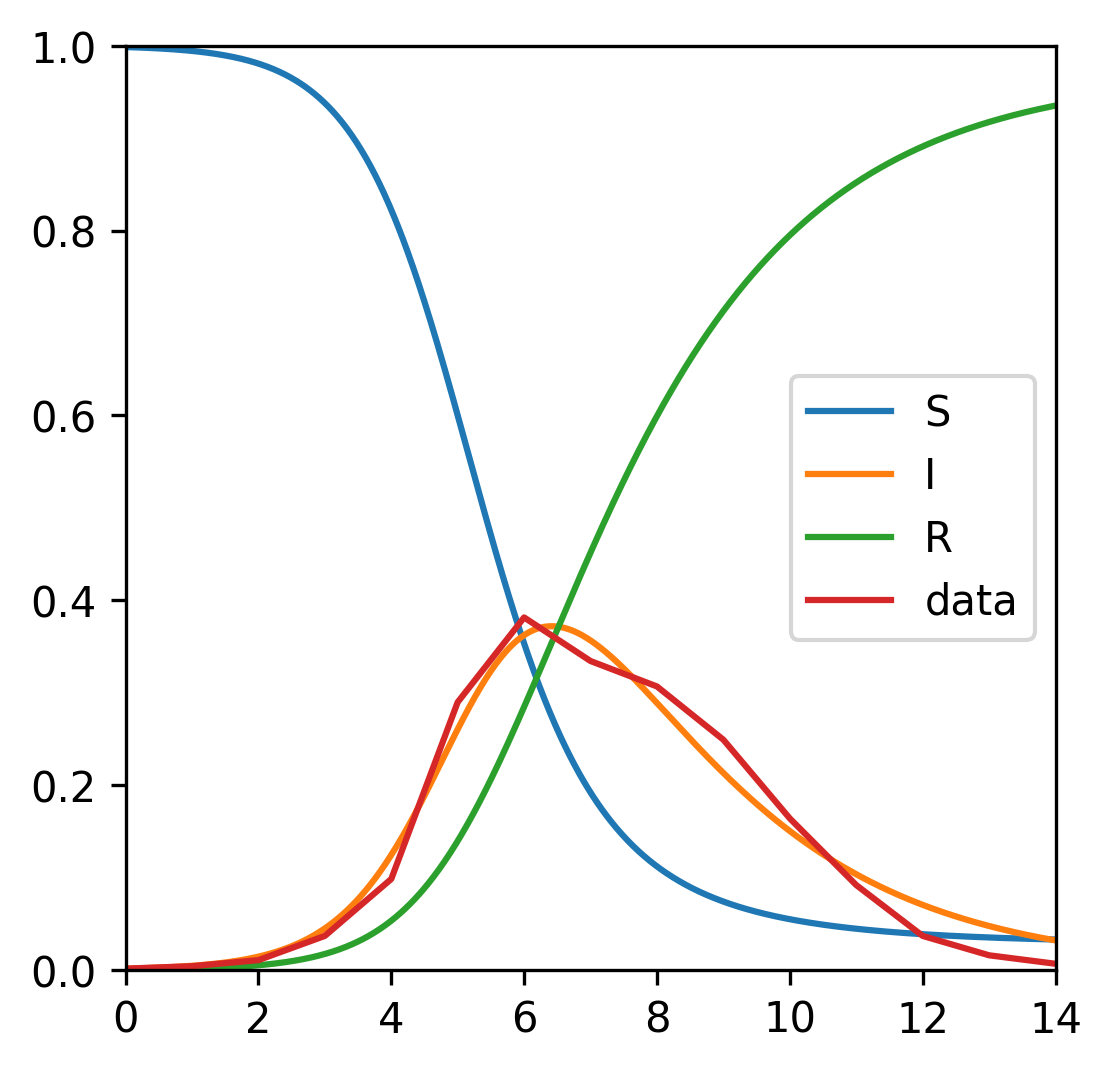

In [89]:
plt.tight_layout
plt.ylim(0,1)
plt.xlim(0,14)
plt.plot(t, sol[:,0], label="S")
plt.plot(t, sol[:,1], label="I")
plt.plot(t, sol[:,2], label="R")
plt.plot(np.linspace(0,14,15), np.array([1,3,8,28,75,221,291,255,234,190,125,70,28,12,5])/763, label="data")
plt.legend()
plt.show()

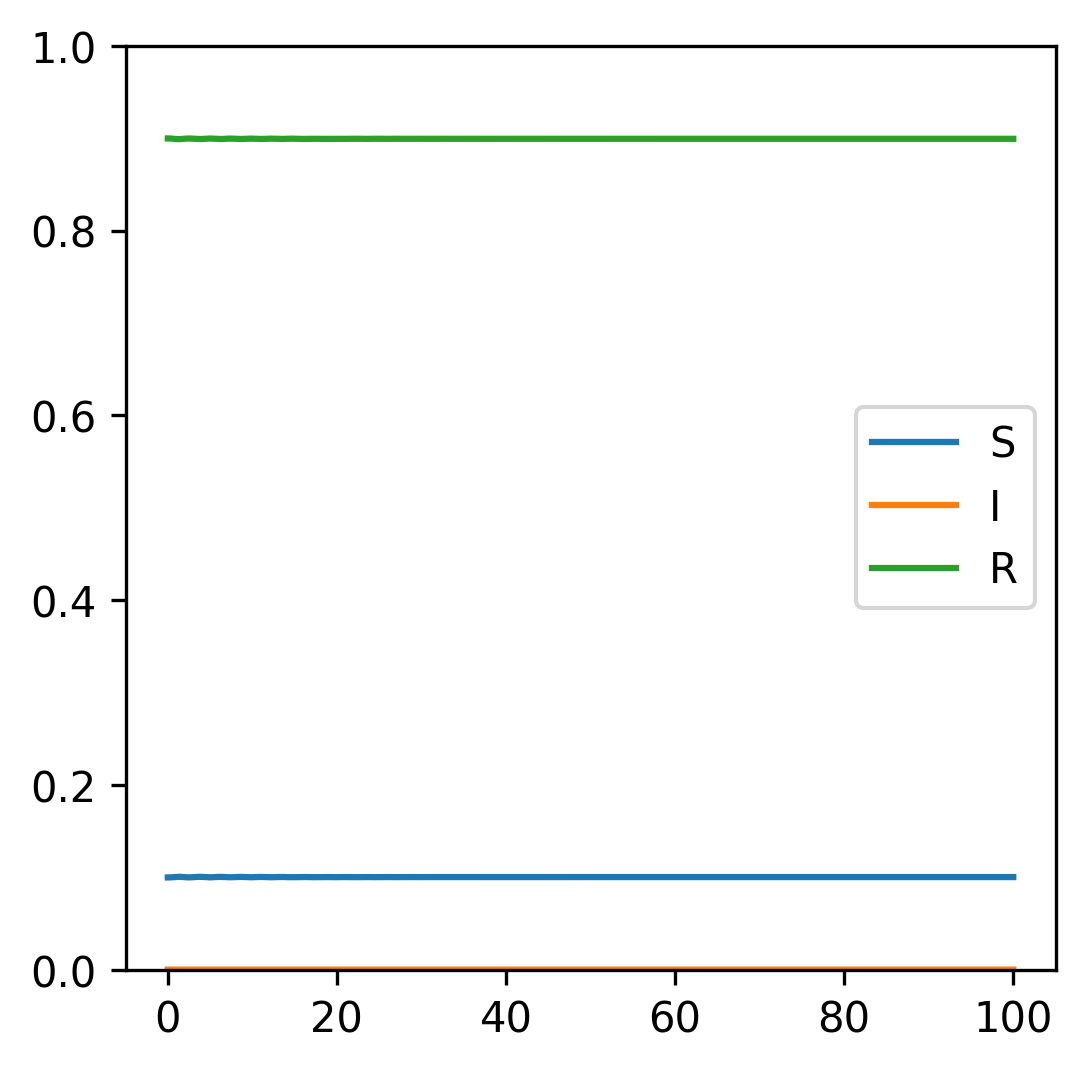

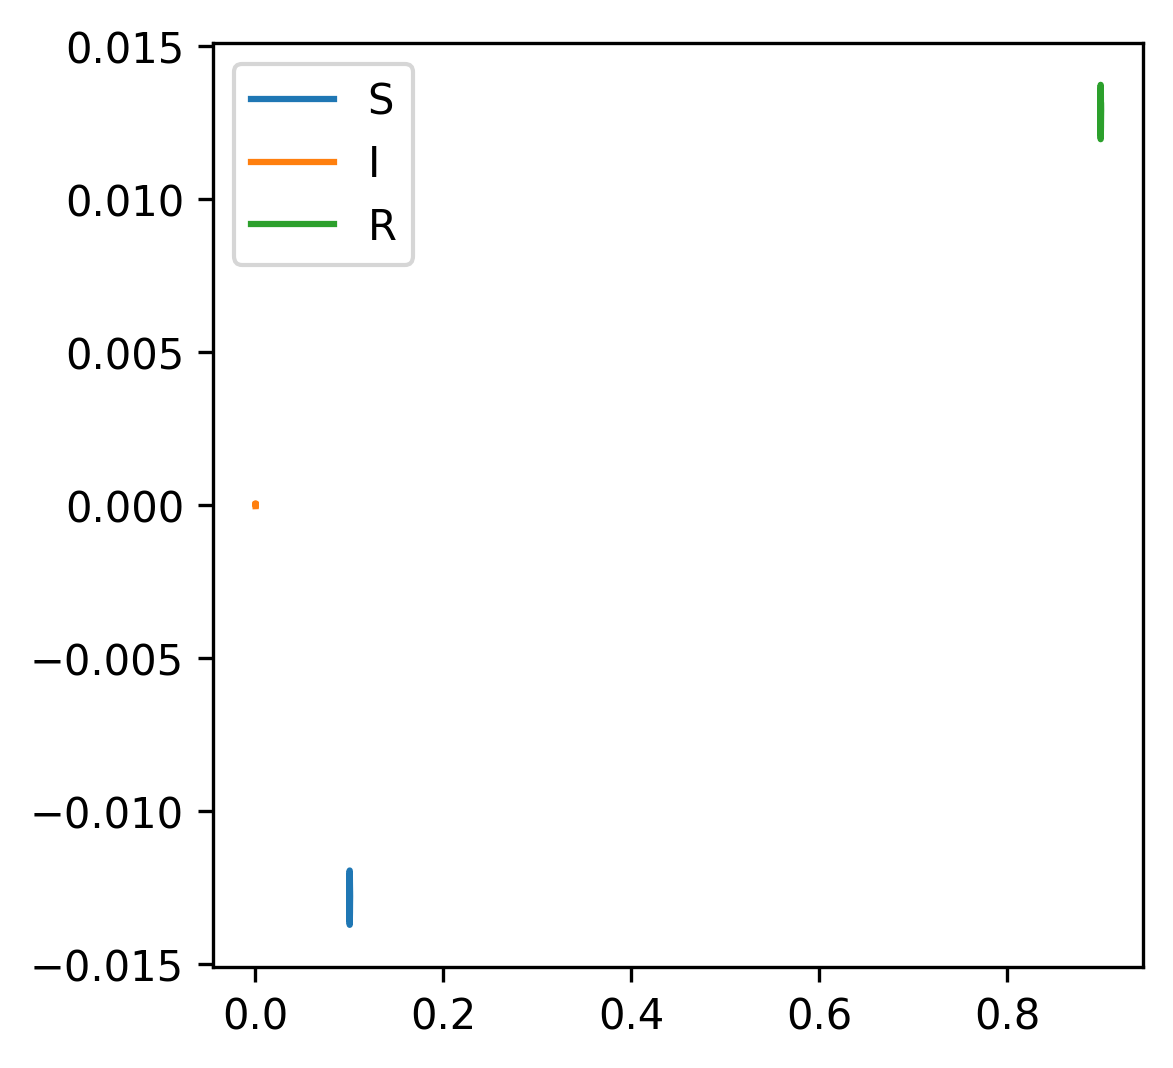

In [101]:
t = np.linspace(0,100, 1000)
y0 = np.array([0.1, 2.5e-4, 1-.1-2.5e-4])
sol, sol_dot = analyse_SIR(520, 365.25/7, 1/70, y0, t)

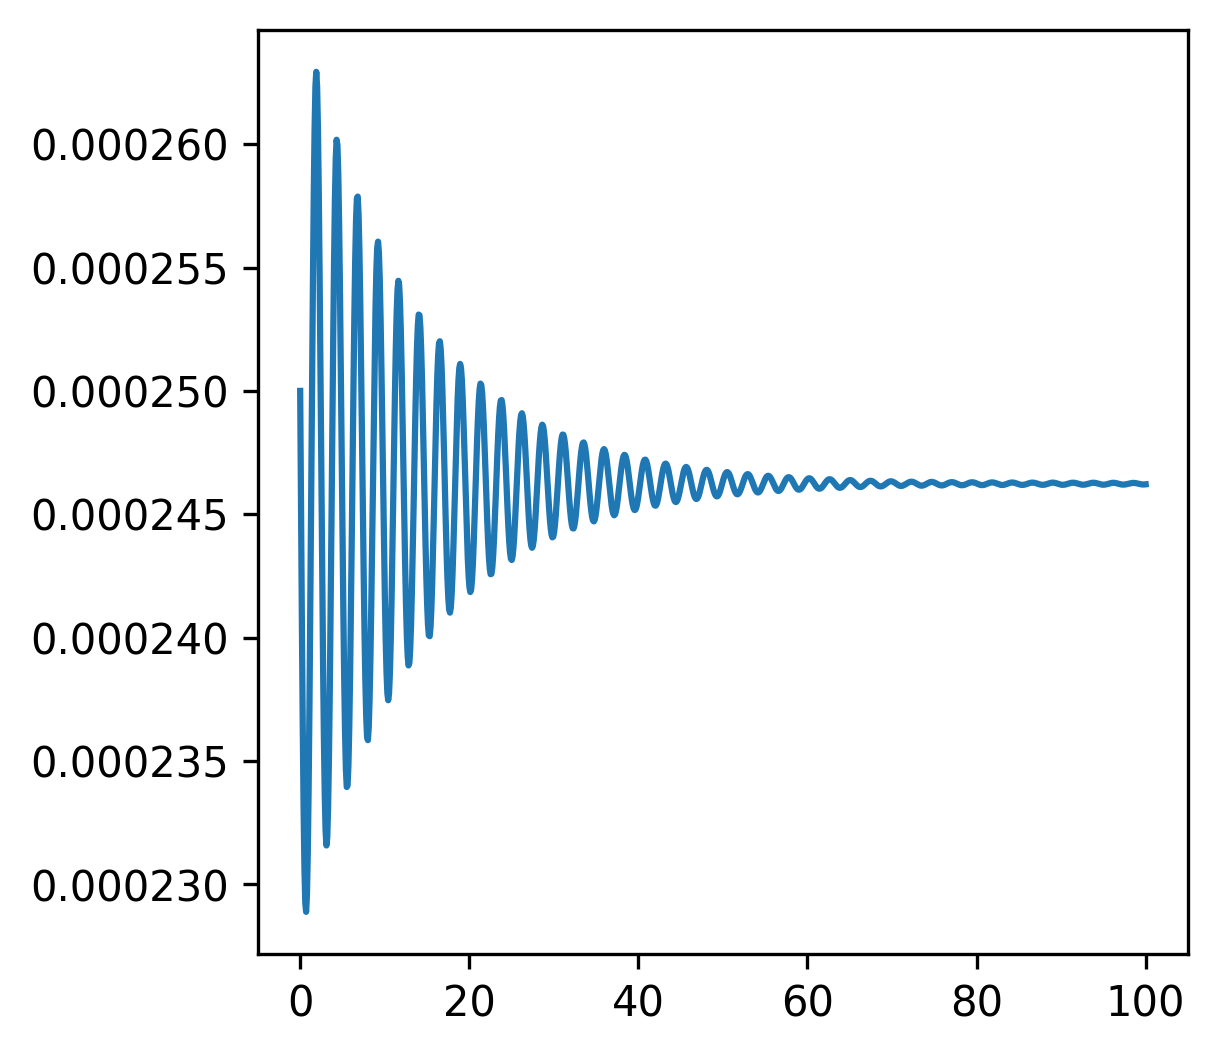

In [102]:
plt.plot(t[:], sol[:,1])

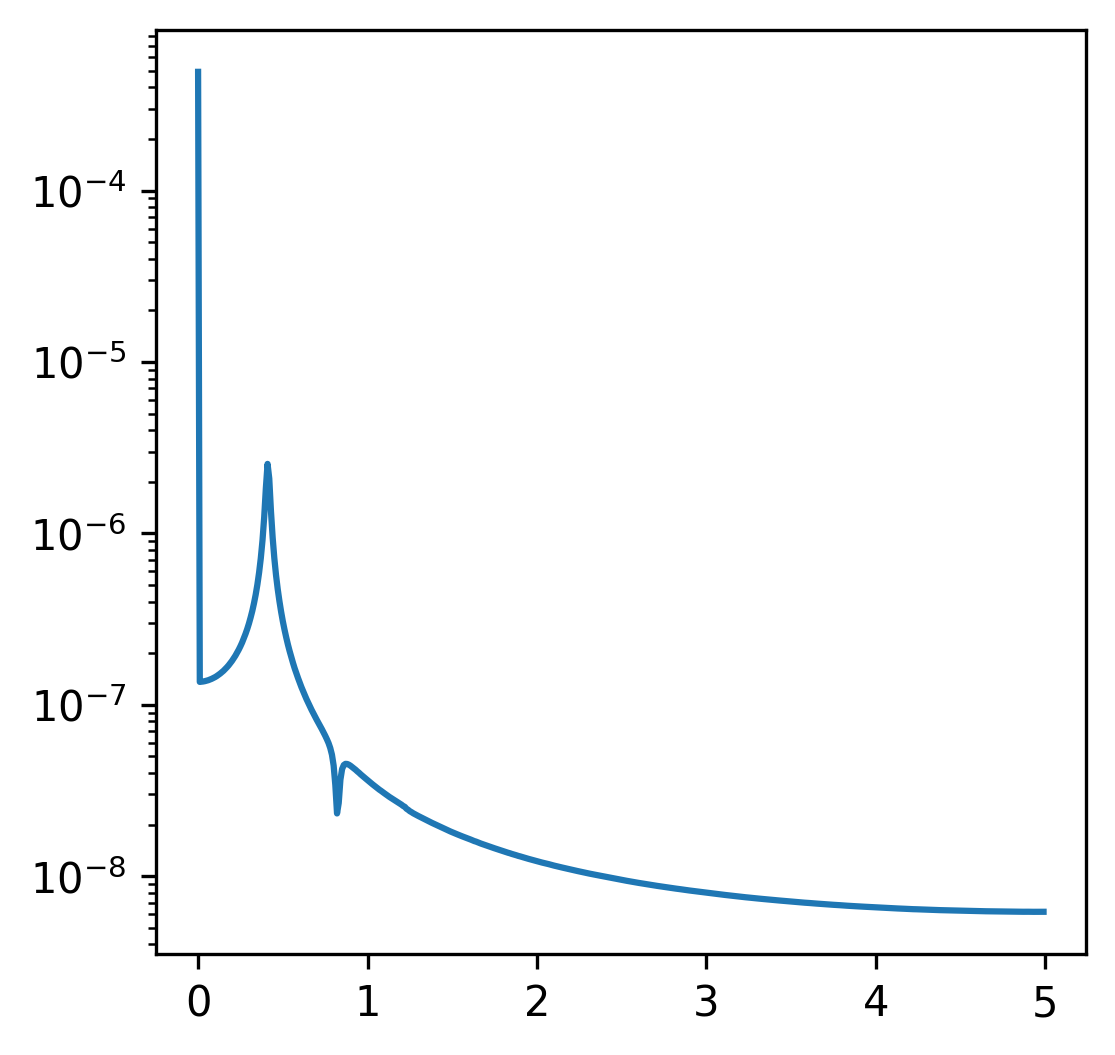

In [119]:
I = sol[:,1]
N = sol[:,1].size
yf = sp.fft.fft(I)
xf = sp.fft.fftfreq(N, 1/10)[:N//2]
plt.yscale("log")
plt.plot(xf, 2/N * np.abs(yf[0:N//2]))
